In [2]:
import sys
import os
sys.path.append('..')
os.chdir('..')  # change working directory to project root

import torch
import matplotlib.pyplot as plt
import numpy as np
from transformer import make_transformer
from data import build_dataloaders, tokenize, SOS_IDX, EOS_IDX, PAD_IDX

device = torch.device('cpu')
_, _, src_vocab, tgt_vocab = build_dataloaders(batch_size=32)

model = make_transformer(
    src_vocab_size=len(src_vocab),
    tgt_vocab_size=len(tgt_vocab),
    d_model=256, h=8, N=3, d_ff=512, dropout=0.0
).to(device)

model.load_state_dict(torch.load('checkpoints/best_model.pt', map_location=device))
model.eval()
print('Model loaded.')

Source vocab size: 9597
Target vocab size: 7704
Train samples: 29000
Val samples:   1014
Model loaded.


In [4]:
def get_attention_weights(sentence, model, src_vocab, tgt_vocab, device):
    tokens = tokenize(sentence)
    src_ids = [SOS_IDX] + src_vocab.encode(tokens) + [EOS_IDX]
    src = torch.tensor([src_ids], dtype=torch.long, device=device)
    src_mask = (src != PAD_IDX).unsqueeze(1).unsqueeze(2)
    src_tokens = ['<sos>'] + tokens + ['<eos>']

    with torch.no_grad():
        enc_out = model.encode(src, src_mask)
        tgt = torch.tensor([[SOS_IDX]], dtype=torch.long, device=device)
        tgt_tokens = ['<sos>']

        for _ in range(50):
            tgt_mask = torch.tril(torch.ones(1, 1, tgt.size(1), tgt.size(1))).bool()
            dec_out = model.decode(tgt, enc_out, src_mask, tgt_mask)
            logits = model.projection(dec_out[:, -1, :])
            next_token = logits.argmax(dim=-1).unsqueeze(0)
            tgt = torch.cat([tgt, next_token], dim=1)
            tgt_tokens.append(tgt_vocab.idx2token.get(next_token.item(), '<unk>'))
            if next_token.item() == EOS_IDX:
                tgt_tokens.append('<eos>')
                break

    attn_weights = model.decoder.layers[-1].cross_attention.attention_weights
    return attn_weights.squeeze(0).cpu().numpy(), src_tokens, tgt_tokens


def plot_attention_heads(weights, src_tokens, tgt_tokens, sentence):
    fig, axes = plt.subplots(2, 4, figsize=(20, 10))
    fig.suptitle(f'Cross-Attention Weights\n"{sentence}"', fontsize=14)

    for h, ax in enumerate(axes.flat):
        w = weights[h, :len(tgt_tokens), :len(src_tokens)]
        im = ax.imshow(w, cmap='Blues', aspect='auto')
        ax.set_xticks(range(len(src_tokens)))
        ax.set_yticks(range(len(tgt_tokens)))
        ax.set_xticklabels(src_tokens, rotation=45, ha='right', fontsize=8)
        ax.set_yticklabels(tgt_tokens, fontsize=8)
        ax.set_title(f'Head {h+1}')
        plt.colorbar(im, ax=ax)

    plt.tight_layout()
    plt.savefig('../attention_maps.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved to attention_maps.png')

Attention weight shape: (8, 6, 7)
Source tokens: ['<sos>', 'ein', 'mann', 'spielt', 'gitarre', '.', '<eos>']
Target tokens: ['<sos>', 'a', 'man', 'playing', 'a', 'guitar', '<eos>', '<eos>']


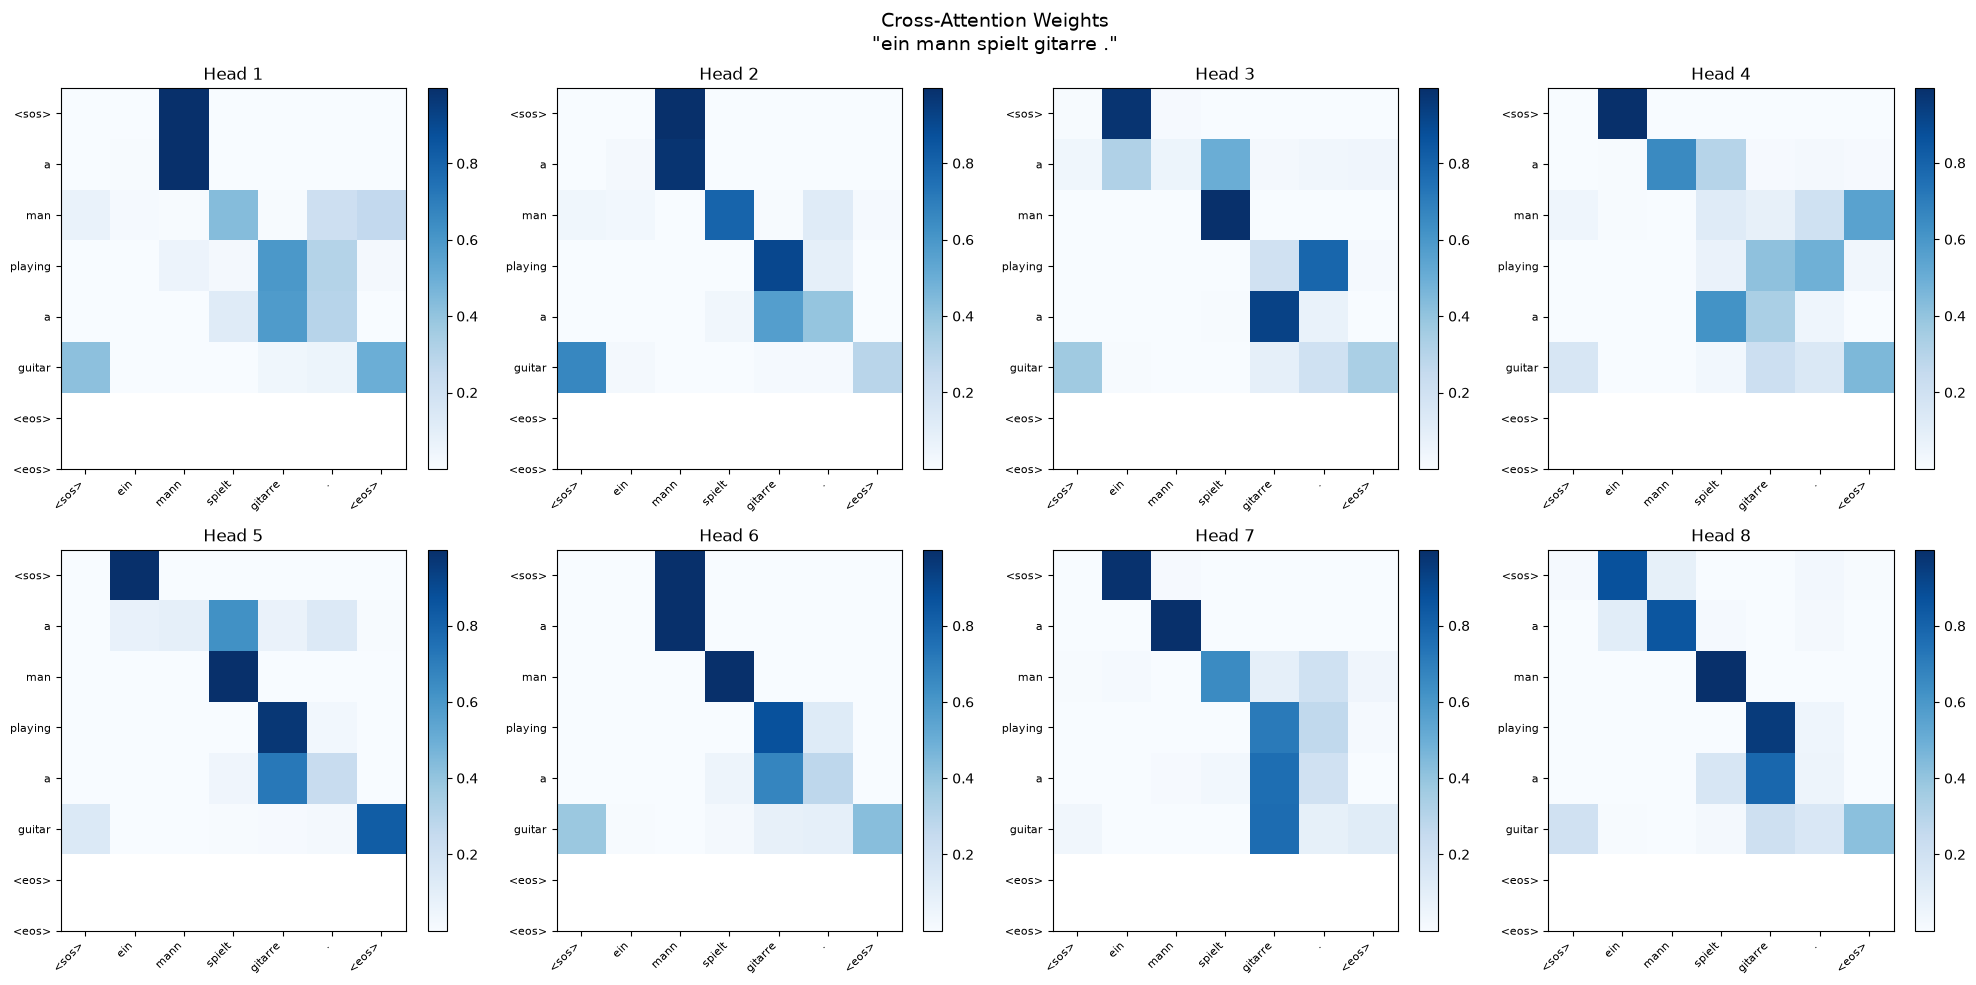

Saved to attention_maps.png


In [5]:
sentence = 'ein mann spielt gitarre .'
weights, src_tokens, tgt_tokens = get_attention_weights(sentence, model, src_vocab, tgt_vocab, device)
print(f'Attention weight shape: {weights.shape}')
print(f'Source tokens: {src_tokens}')
print(f'Target tokens: {tgt_tokens}')
plot_attention_heads(weights, src_tokens, tgt_tokens, sentence)